# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram

from ewfs import EWFS, decode_results, MAJORITY_VOTE
from ewfs.setting import PEEK, REVERSE_2
from ewfs.noise_models import depolarizing_model

## Sanity checks (for majority vote approach)

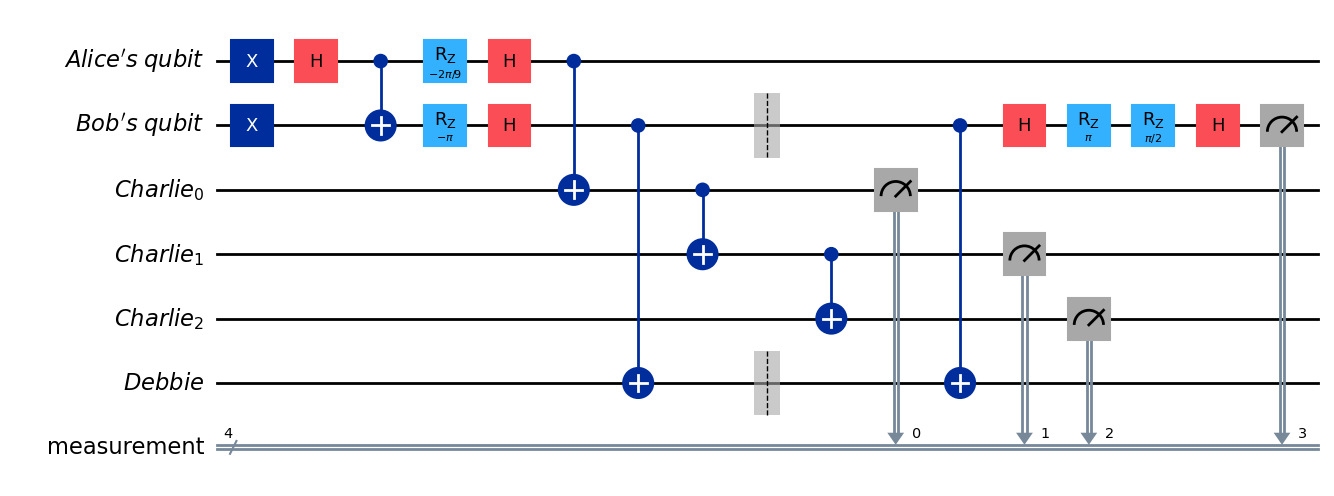

In [2]:
alice_setting = PEEK
bob_setting = REVERSE_2
charlie_size = 3
debbie_size = 1
strategy = MAJORITY_VOTE

ewfs = EWFS(
    alice_setting=alice_setting,
    bob_setting=bob_setting,
    strategy=strategy,
    charlie_size=charlie_size,
    debbie_size=debbie_size,
)
qc = ewfs.circuit()
qc.draw("mpl", style="default")

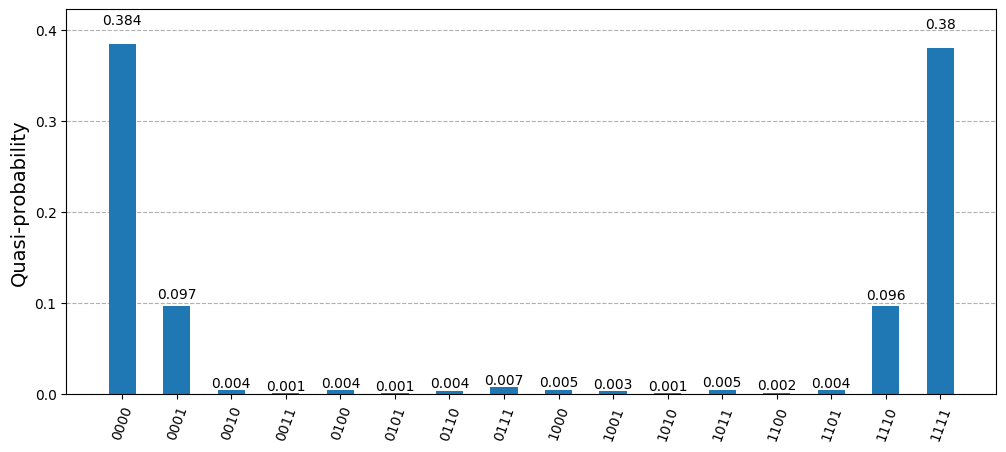

In [3]:
# lots of noise
noise_model = depolarizing_model(circ=qc, single_qubit_error_rate=0.001, two_qubit_error_rate=0.01, meas_error_rate=0.01)
# Create noisy simulator backend
sim_noise = AerSimulator(noise_model=noise_model)

shots = 10_000
job = sim_noise.run(qc, shots=shots)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / shots for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

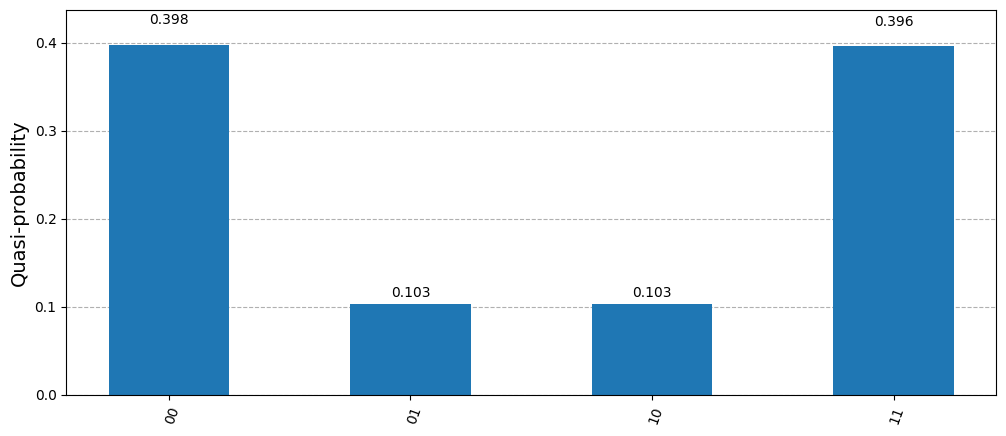

In [4]:
results = {(alice_setting, bob_setting): probabilities}
dec_res = decode_results(results, charlie_size=charlie_size, debbie_size=debbie_size)
probs = dec_res[(alice_setting, bob_setting)]
plot_distribution(probs, figsize=(12, 5))

## Experiment

Run EWFS experiment for a specific number of shots, trials, and over a range of friend sizes.

#### Settings

In [5]:
from ewfs import run_experiment, SEMI_BRUKNER_SETTINGS

run_experiment(settings=SEMI_BRUKNER_SETTINGS, strategy="random")

Trial 1 out of 2 for task of 1_1
Task with task ID: 9727593a-960b-413d-9dbe-affc711097c5

Trial 2 out of 2 for task of 1_1
Task with task ID: 9c9e1459-3fef-4f5f-9cda-ad838e2a826f

Trial 1 out of 2 for task of 2_1
Task with task ID: 3a6bd700-e8f1-469b-891c-7f81a5ee8585

Trial 2 out of 2 for task of 2_1
Task with task ID: 990da97e-9069-41d0-957d-d071cc7f5375

Processing trial 1 for task with task ID: 9727593a-960b-413d-9dbe-affc711097c5
Results: {('peek', 'reverse_1'): {'10': 0.4083, '00': 0.0854, '11': 0.0876, '01': 0.4187}, ('peek', 'reverse_2'): {'10': 0.0935, '01': 0.0869, '00': 0.4028, '11': 0.4168}, ('reverse_2', 'reverse_1'): {'10': 0.4378, '00': 0.0595, '11': 0.0572, '01': 0.4455}, ('reverse_2', 'reverse_2'): {'11': 0.056, '00': 0.0617, '01': 0.4496, '10': 0.4327}}
semi_brukner=0.8243999999999998 -- is violated: True
Violations: {'semi_brukner': 0.8243999999999998}

Post-processed results: defaultdict(<function run_experiment.<locals>.<lambda> at 0x12b42d800>, {'1_1': defaultdict

defaultdict(<function ewfs.experiment.run_experiment.<locals>.<lambda>()>,
            {'1_1': defaultdict(list,
                         {'semi_brukner': [0.8243999999999998,
                           0.8200000000000003]}),
             '2_1': defaultdict(list,
                         {'semi_brukner': [0.7936000000000001,
                           0.7814000000000001]})})